# COM763 Portfolio Task 1  
## End-to-End Machine Learning Pipeline for Breast Cancer Diagnostic Classification

**Real-world problem:** classify digitised fine-needle aspiration measurements as
**benign** or **malignant-like**.

**Important deployment boundary:** this project is an educational machine-learning
demonstration. It is not a clinical diagnostic device and must not replace qualified
medical assessment.

### Pipeline map
1. Reproducible setup  
2. Data loading and audit  
3. Exploratory analysis  
4. Leakage-safe train/test split  
5. Preprocessing pipeline  
6. Baseline and candidate-model comparison  
7. Hyperparameter tuning  
8. Decision-threshold selection  
9. Final held-out evaluation  
10. Explainability and engineering checks  
11. Model export for Streamlit

# 1. Reproducible Setup

The random seed is fixed so that data splitting, cross-validation and model training
can be repeated. Parallel processing is deliberately limited to one worker so the
notebook runs reliably on ordinary laptops and hosted notebook environments.

In [1]:
# Core numerical and data libraries
from pathlib import Path
import json
import platform
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Scikit-learn data, pipelines, models and evaluation
import sklearn
from sklearn.base import clone
from sklearn.datasets import load_breast_cancer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    fbeta_score,
    make_scorer,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.utils.validation import check_is_fitted

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.20
N_SPLITS = 5
N_JOBS = 1

PROJECT_ROOT = Path.cwd()
MODEL_DIR = PROJECT_ROOT / "model"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Python:", platform.python_version())
print("scikit-learn:", sklearn.__version__)
print("Project root:", PROJECT_ROOT)

Python: 3.13.5
scikit-learn: 1.8.0
Project root: /mnt/data/COM763_Task1_Breast_Cancer_ML


# 2. Problem Definition and Success Criteria

## Machine-learning formulation
- **Task:** supervised binary classification.
- **Input:** 30 numeric measurements calculated from cell-nucleus images.
- **Output:** `0 = benign`, `1 = malignant`.
- **Primary metric:** F2 score, which gives recall more weight than precision.
- **Supporting metrics:** malignant recall, precision, F1, ROC-AUC, average precision
  and confusion-matrix counts.
- **Generalisation test:** one stratified 20% hold-out set that is not used during
  preprocessing, model comparison, tuning or threshold selection.

In [2]:
# F2 weights recall more heavily than precision.
f2_scorer = make_scorer(fbeta_score, beta=2, zero_division=0)

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "f2": f2_scorer,
    "roc_auc": "roc_auc",
}

# 3. Load the Dataset

In [3]:
# The dataset is packaged with scikit-learn, so the project is reproducible
# without downloading data from an external website.
dataset = load_breast_cancer(as_frame=True)

X = dataset.data.copy()

# Original sklearn coding: 0 = malignant and 1 = benign.
# Remap the positive class to 1 = malignant to prevent metric confusion.
y = (dataset.target == 0).astype(int)
y.name = "malignant"

df = X.copy()
df[y.name] = y

print("Dataset shape:", df.shape)
print("Number of predictors:", X.shape[1])
print("Target coding:", {0: "Benign", 1: "Malignant"})
df.head()

Dataset shape: (569, 31)
Number of predictors: 30
Target coding: {0: 'Benign', 1: 'Malignant'}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,malignant
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


# 4. Data Audit and Quality Checks

In [4]:
# Dataset structure and data types
audit_summary = pd.DataFrame({
    "dtype": X.dtypes.astype(str),
    "missing_values": X.isna().sum(),
    "unique_values": X.nunique(),
    "minimum": X.min(),
    "maximum": X.max(),
})

print("Duplicate rows:", int(X.duplicated().sum()))
print("Missing predictor values:", int(X.isna().sum().sum()))
print("Infinite values:", int(np.isinf(X.to_numpy()).sum()))
audit_summary.head(10)

Duplicate rows: 0
Missing predictor values: 0
Infinite values: 0


,dtype,missing_values,unique_values,minimum,maximum
mean radius,float64,0,456,6.98100,28.11000
mean texture,float64,0,479,9.71000,39.28000
mean perimeter,float64,0,522,43.79000,188.50000
mean area,float64,0,539,143.50000,2501.00000
mean smoothness,float64,0,474,0.05263,0.16340
mean compactness,float64,0,537,0.01938,0.34540
mean concavity,float64,0,537,0.00000,0.42680
mean concave points,float64,0,542,0.00000,0.20120
mean symmetry,float64,0,432,0.10600,0.30400
mean fractal dimension,float64,0,499,0.04996,0.09744


In [5]:
# Fail early if the raw data violate basic assumptions.
assert len(X) == len(y), "Predictor and target row counts do not match."
assert X.shape[1] == 30, "Unexpected number of features."
assert set(np.unique(y)) == {0, 1}, "Target must be binary."
assert np.isfinite(X.to_numpy()).all(), "Non-finite values detected."

print("All initial data-integrity assertions passed.")

All initial data-integrity assertions passed.


# 5. Exploratory Data Analysis

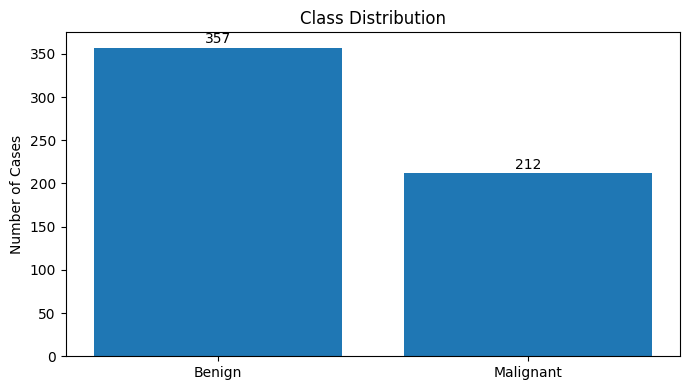

,class,count,percentage
0,Benign,357,62.74
1,Malignant,212,37.26


In [6]:
# Class distribution
class_counts = y.value_counts().sort_index()
class_labels = ["Benign", "Malignant"]

plt.figure(figsize=(7, 4))
plt.bar(class_labels, class_counts.values)
plt.title("Class Distribution")
plt.ylabel("Number of Cases")
for index, value in enumerate(class_counts.values):
    plt.text(index, value + 5, str(value), ha="center")
plt.tight_layout()
plt.show()

pd.DataFrame({
    "class": class_labels,
    "count": class_counts.values,
    "percentage": (class_counts.values / len(y) * 100).round(2),
})

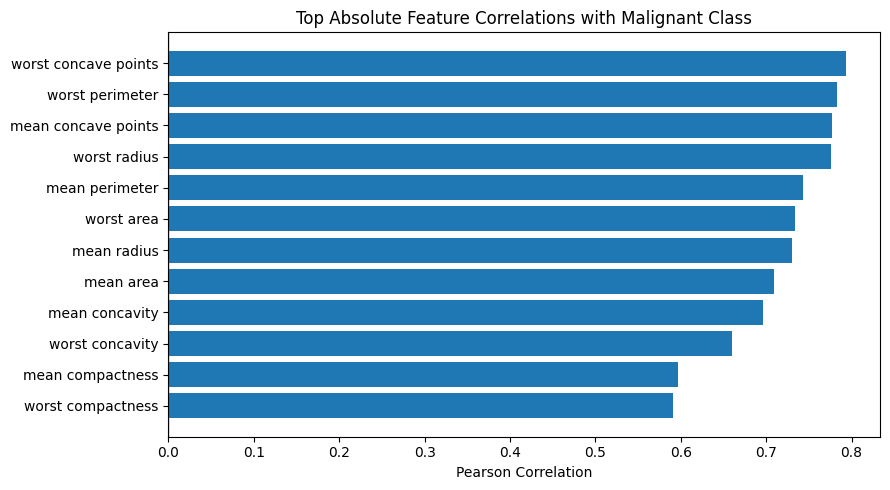

,correlation_with_malignant
worst concave points,0.793566
worst perimeter,0.782914
mean concave points,0.776614
worst radius,0.776454
mean perimeter,0.742636
worst area,0.733825
mean radius,0.730029
mean area,0.708984
mean concavity,0.696360
worst concavity,0.659610


In [7]:
# Identify features most strongly associated with the remapped target.
target_correlations = (
    df.corr(numeric_only=True)["malignant"]
      .drop("malignant")
      .sort_values(key=np.abs, ascending=False)
)

top_correlations = target_correlations.head(12)

plt.figure(figsize=(9, 5))
plt.barh(top_correlations.index[::-1], top_correlations.values[::-1])
plt.axvline(0, linewidth=1)
plt.title("Top Absolute Feature Correlations with Malignant Class")
plt.xlabel("Pearson Correlation")
plt.tight_layout()
plt.show()

top_correlations.to_frame("correlation_with_malignant")

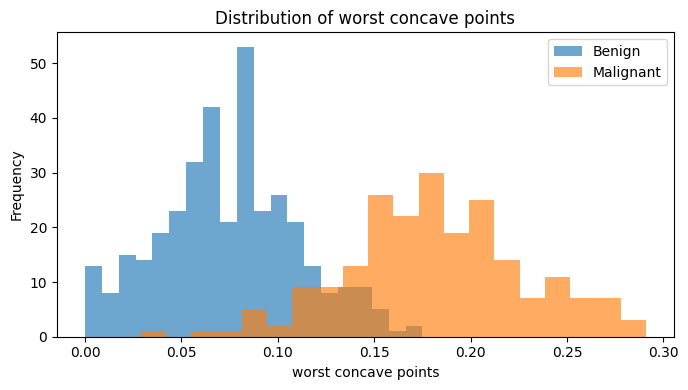

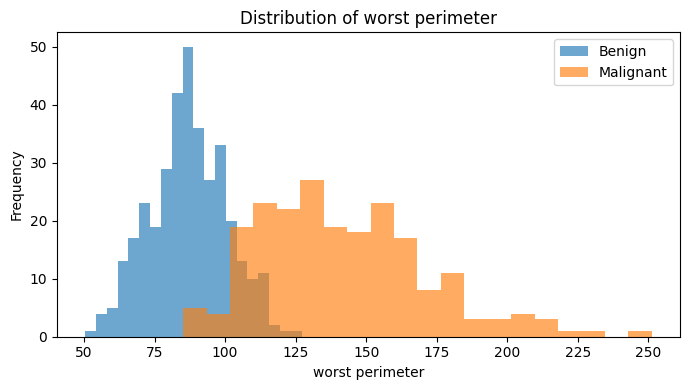

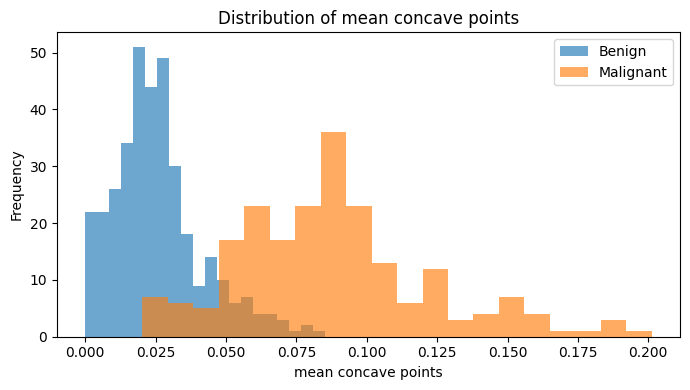

In [8]:
# Distribution plot for the three strongest individual features.
top_three_features = top_correlations.index[:3].tolist()

for feature in top_three_features:
    plt.figure(figsize=(7, 4))
    plt.hist(
        X.loc[y == 0, feature],
        bins=20,
        alpha=0.65,
        label="Benign",
    )
    plt.hist(
        X.loc[y == 1, feature],
        bins=20,
        alpha=0.65,
        label="Malignant",
    )
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

# 6. Leakage-Safe Train/Test Split

The hold-out test set is created before any imputation, scaling, cross-validation or
hyperparameter tuning. Stratification preserves the benign/malignant proportion.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

# Engineering checks: no row can occur in both partitions.
assert set(X_train.index).isdisjoint(set(X_test.index))
assert X_train.columns.tolist() == X_test.columns.tolist()

split_summary = pd.DataFrame({
    "partition": ["Training", "Test"],
    "rows": [len(X_train), len(X_test)],
    "malignant_count": [int(y_train.sum()), int(y_test.sum())],
    "malignant_rate": [float(y_train.mean()), float(y_test.mean())],
})
split_summary

,partition,rows,malignant_count,malignant_rate
0,Training,455,170,0.373626
1,Test,114,42,0.368421


# 7. Preprocessing Pipeline

In [10]:
# All predictors are numeric.
# Median imputation makes the production pipeline robust to occasional missing values.
# Standardisation is important for Logistic Regression, SVM and KNN.
preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Debug the transformer independently using training data only.
preprocessor_check = clone(preprocessor)
X_train_transformed = preprocessor_check.fit_transform(X_train)

assert X_train_transformed.shape == X_train.shape
assert np.isfinite(X_train_transformed).all()

print("Transformed training shape:", X_train_transformed.shape)
print("Preprocessing debug checks passed.")

Transformed training shape: (455, 30)
Preprocessing debug checks passed.


# 8. Baseline and Candidate Model Comparison

In [11]:
# A dummy model establishes the no-skill baseline.
candidate_models = {
    "Dummy Baseline": DummyClassifier(
        strategy="prior",
        random_state=RANDOM_STATE,
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "RBF SVM": SVC(
        probability=True,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS,
    ),
    "K-Nearest Neighbours": KNeighborsClassifier(
        n_neighbors=7,
        weights="distance",
    ),
}

cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

comparison_rows = []

for model_name, estimator in candidate_models.items():
    pipeline = Pipeline(steps=[
        ("preprocess", clone(preprocessor)),
        ("model", estimator),
    ])

    cv_result = cross_validate(
        estimator=pipeline,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=N_JOBS,
        return_train_score=False,
    )

    row = {"model": model_name}
    for metric_name in scoring:
        values = cv_result[f"test_{metric_name}"]
        row[f"{metric_name}_mean"] = float(np.mean(values))
        row[f"{metric_name}_std"] = float(np.std(values))
    comparison_rows.append(row)

comparison_df = (
    pd.DataFrame(comparison_rows)
      .sort_values("f2_mean", ascending=False)
      .reset_index(drop=True)
)

comparison_df.round(4)

,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,f2_mean,f2_std,roc_auc_mean,roc_auc_std
0,Logistic Regression,0.9714,0.0179,0.9650,0.0286,0.9588,0.0300,0.9616,0.0241,0.9599,0.0266,0.9954,0.0048
1,RBF SVM,0.9692,0.0108,0.9646,0.0101,0.9529,0.0353,0.9583,0.0154,0.9550,0.0272,0.9948,0.0043
2,K-Nearest Neighbours,0.9714,0.0112,0.9879,0.0149,0.9353,0.0288,0.9605,0.0157,0.9452,0.0233,0.9875,0.0142
3,Random Forest,0.9626,0.0132,0.9592,0.0286,0.9412,0.0322,0.9495,0.0178,0.9443,0.0246,0.9886,0.0071
4,Dummy Baseline,0.6264,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5000,0.0000


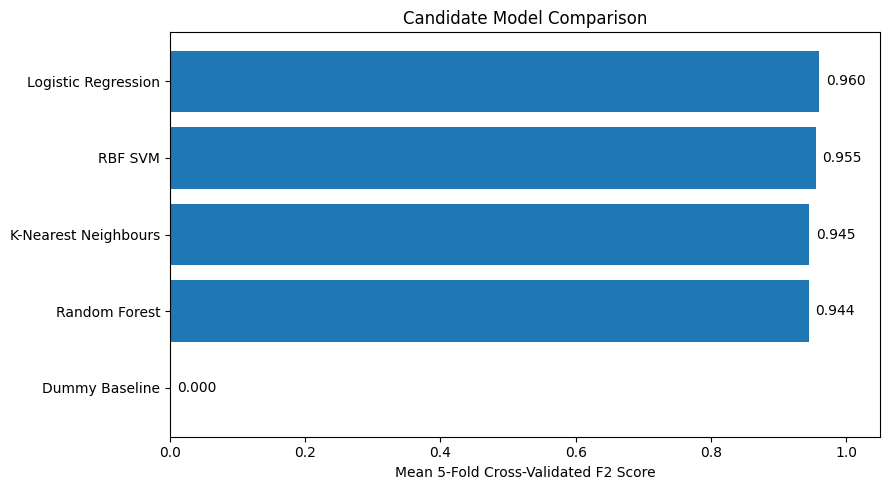

In [12]:
# Model comparison visual
plot_data = comparison_df.sort_values("f2_mean", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(plot_data["model"], plot_data["f2_mean"])
plt.xlim(0, 1.05)
plt.xlabel("Mean 5-Fold Cross-Validated F2 Score")
plt.title("Candidate Model Comparison")
for index, value in enumerate(plot_data["f2_mean"]):
    plt.text(value + 0.01, index, f"{value:.3f}", va="center")
plt.tight_layout()
plt.show()

# 9. Hyperparameter Tuning

The two strongest scalable candidates are tuned using only the training partition.
`GridSearchCV` applies every preprocessing step inside each fold, preventing leakage.

In [13]:
shortlisted_searches = {
    "Logistic Regression": {
        "estimator": Pipeline(steps=[
            ("preprocess", clone(preprocessor)),
            ("model", LogisticRegression(
                max_iter=5000,
                random_state=RANDOM_STATE,
            )),
        ]),
        "param_grid": {
            "model__C": [0.01, 0.1, 1, 10, 100],
            "model__class_weight": [None, "balanced"],
        },
    },
    "RBF SVM": {
        "estimator": Pipeline(steps=[
            ("preprocess", clone(preprocessor)),
            ("model", SVC(
                probability=True,
                random_state=RANDOM_STATE,
            )),
        ]),
        "param_grid": {
            "model__C": [0.1, 1, 10, 100],
            "model__gamma": ["scale", 0.001, 0.01, 0.1],
            "model__class_weight": [None, "balanced"],
        },
    },
}

fitted_searches = {}
tuning_rows = []

for model_name, configuration in shortlisted_searches.items():
    search = GridSearchCV(
        estimator=configuration["estimator"],
        param_grid=configuration["param_grid"],
        scoring=f2_scorer,
        cv=cv,
        refit=True,
        n_jobs=N_JOBS,
        return_train_score=True,
    )
    search.fit(X_train, y_train)
    fitted_searches[model_name] = search

    tuning_rows.append({
        "model": model_name,
        "best_cv_f2": float(search.best_score_),
        "best_parameters": search.best_params_,
    })

tuning_df = pd.DataFrame(tuning_rows).sort_values(
    "best_cv_f2",
    ascending=False,
).reset_index(drop=True)

tuning_df

,model,best_cv_f2,best_parameters
0,RBF SVM,0.965677,"{'model__C': 10, 'model__class_weight': None, ..."
1,Logistic Regression,0.959873,"{'model__C': 1, 'model__class_weight': 'balanc..."


In [14]:
# Select the tuned model using cross-validated F2 performance.
selected_model_name = tuning_df.loc[0, "model"]
selected_search = fitted_searches[selected_model_name]
selected_estimator = clone(selected_search.best_estimator_)

print("Selected model:", selected_model_name)
print("Best training CV F2:", round(selected_search.best_score_, 4))
print("Best parameters:", selected_search.best_params_)

Selected model: RBF SVM
Best training CV F2: 0.9657
Best parameters: {'model__C': 10, 'model__class_weight': None, 'model__gamma': 'scale'}


# 10. Decision-Threshold Selection

The default probability threshold of 0.50 is not automatically optimal. Out-of-fold
probabilities from the training data are used to choose a threshold. The selection
rule maximises F2 among thresholds that achieve at least 0.95 recall on the
out-of-fold training predictions.

In [15]:
oof_probabilities = cross_val_predict(
    estimator=selected_estimator,
    X=X_train,
    y=y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=N_JOBS,
)[:, 1]

threshold_rows = []

for threshold in np.arange(0.05, 0.951, 0.01):
    oof_predictions = (oof_probabilities >= threshold).astype(int)
    threshold_rows.append({
        "threshold": float(threshold),
        "precision": precision_score(
            y_train, oof_predictions, zero_division=0
        ),
        "recall": recall_score(
            y_train, oof_predictions, zero_division=0
        ),
        "f2": fbeta_score(
            y_train, oof_predictions, beta=2, zero_division=0
        ),
    })

threshold_df = pd.DataFrame(threshold_rows)
eligible_thresholds = threshold_df[threshold_df["recall"] >= 0.95]

if not eligible_thresholds.empty:
    selected_threshold_row = (
        eligible_thresholds
        .sort_values(["f2", "precision"], ascending=False)
        .iloc[0]
    )
else:
    selected_threshold_row = threshold_df.loc[
        threshold_df["f2"].idxmax()
    ]

selected_threshold = float(selected_threshold_row["threshold"])
selected_threshold_row.to_frame("selected_value")

,selected_value
threshold,0.570000
precision,0.976190
recall,0.964706
f2,0.966981


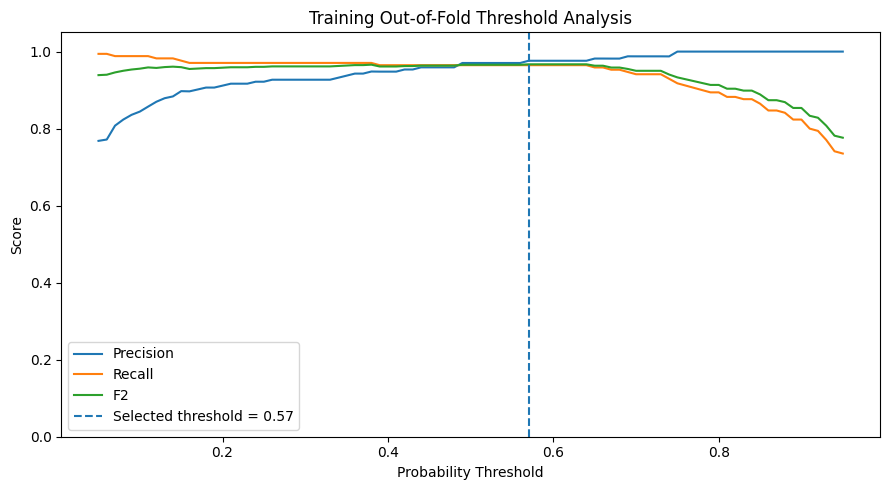

In [16]:
plt.figure(figsize=(9, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f2"], label="F2")
plt.axvline(
    selected_threshold,
    linestyle="--",
    label=f"Selected threshold = {selected_threshold:.2f}",
)
plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.title("Training Out-of-Fold Threshold Analysis")
plt.legend()
plt.tight_layout()
plt.show()

# 11. Final Model Fit and Held-Out Evaluation

In [17]:
# Fit once on the complete training partition.
final_model = clone(selected_search.best_estimator_)
final_model.fit(X_train, y_train)
check_is_fitted(final_model)

# Evaluate once on the untouched test partition.
test_probabilities = final_model.predict_proba(X_test)[:, 1]
test_predictions = (
    test_probabilities >= selected_threshold
).astype(int)

assert np.all((test_probabilities >= 0) & (test_probabilities <= 1))
assert len(test_predictions) == len(y_test)

test_metrics = {
    "accuracy": accuracy_score(y_test, test_predictions),
    "precision_malignant": precision_score(
        y_test, test_predictions, zero_division=0
    ),
    "recall_malignant": recall_score(
        y_test, test_predictions, zero_division=0
    ),
    "f1_malignant": f1_score(
        y_test, test_predictions, zero_division=0
    ),
    "f2_malignant": fbeta_score(
        y_test, test_predictions, beta=2, zero_division=0
    ),
    "roc_auc": roc_auc_score(y_test, test_probabilities),
    "average_precision": average_precision_score(
        y_test, test_probabilities
    ),
}

pd.DataFrame.from_dict(
    test_metrics,
    orient="index",
    columns=["held_out_test_value"],
).round(4)

,held_out_test_value
accuracy,0.9737
precision_malignant,1.0000
recall_malignant,0.9286
f1_malignant,0.9630
f2_malignant,0.9420
roc_auc,0.9927
average_precision,0.9907


In [18]:
print(
    classification_report(
        y_test,
        test_predictions,
        target_names=["Benign", "Malignant"],
        zero_division=0,
    )
)

              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



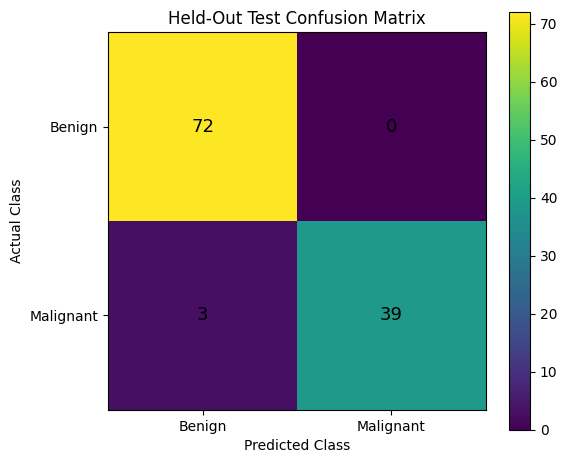

,Predicted Benign,Predicted Malignant
Actual Benign,72,0
Actual Malignant,3,39


In [19]:
# Confusion matrix: rows are actual classes and columns are predicted classes.
cm = confusion_matrix(y_test, test_predictions)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Held-Out Test Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.xticks([0, 1], ["Benign", "Malignant"])
plt.yticks([0, 1], ["Benign", "Malignant"])

for row in range(cm.shape[0]):
    for column in range(cm.shape[1]):
        plt.text(
            column,
            row,
            str(cm[row, column]),
            ha="center",
            va="center",
            fontsize=13,
        )

plt.colorbar()
plt.tight_layout()
plt.show()

pd.DataFrame(
    cm,
    index=["Actual Benign", "Actual Malignant"],
    columns=["Predicted Benign", "Predicted Malignant"],
)

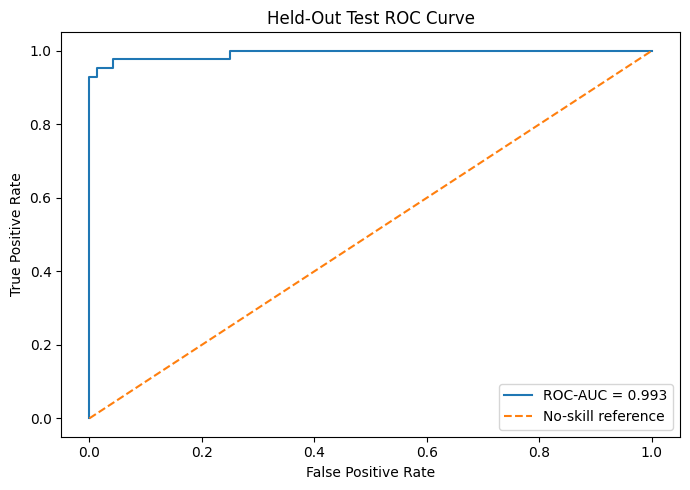

In [20]:
false_positive_rate, true_positive_rate, _ = roc_curve(
    y_test,
    test_probabilities,
)

plt.figure(figsize=(7, 5))
plt.plot(
    false_positive_rate,
    true_positive_rate,
    label=f"ROC-AUC = {test_metrics['roc_auc']:.3f}",
)
plt.plot([0, 1], [0, 1], linestyle="--", label="No-skill reference")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Held-Out Test ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

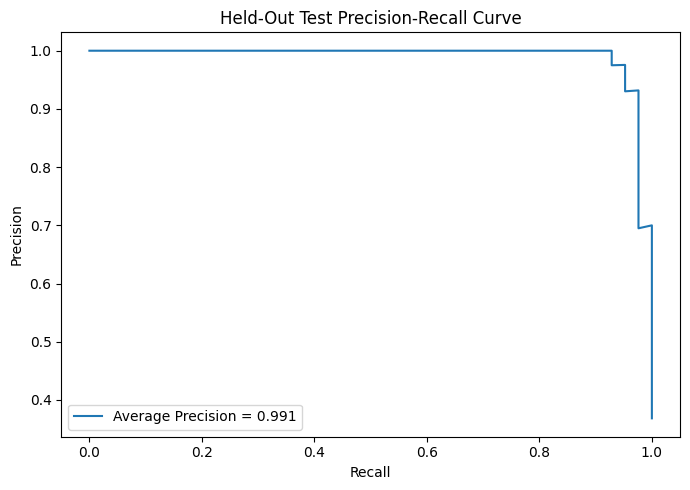

In [21]:
pr_precision, pr_recall, _ = precision_recall_curve(
    y_test,
    test_probabilities,
)

plt.figure(figsize=(7, 5))
plt.plot(
    pr_recall,
    pr_precision,
    label=(
        "Average Precision = "
        f"{test_metrics['average_precision']:.3f}"
    ),
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Held-Out Test Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.show()

# 12. Model Explainability with Permutation Importance

In [22]:
# Permutation importance measures the decrease in held-out F2 when each
# feature is randomly shuffled. It is model-agnostic and uses the test data.
importance_result = permutation_importance(
    estimator=final_model,
    X=X_test,
    y=y_test,
    scoring=f2_scorer,
    n_repeats=15,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
)

importance_df = (
    pd.DataFrame({
        "feature": X.columns,
        "importance_mean": importance_result.importances_mean,
        "importance_std": importance_result.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

importance_df.head(12).round(5)

,feature,importance_mean,importance_std
0,worst texture,0.05046,0.02759
1,worst concavity,0.03809,0.01757
2,mean concavity,0.03230,0.02290
3,worst smoothness,0.01204,0.01331
4,worst concave points,0.00909,0.01235
5,mean texture,0.00474,0.00645
6,smoothness error,0.00293,0.00667
7,worst perimeter,0.00156,0.01414
8,fractal dimension error,0.00037,0.01567
9,concave points error,0.00030,0.00113


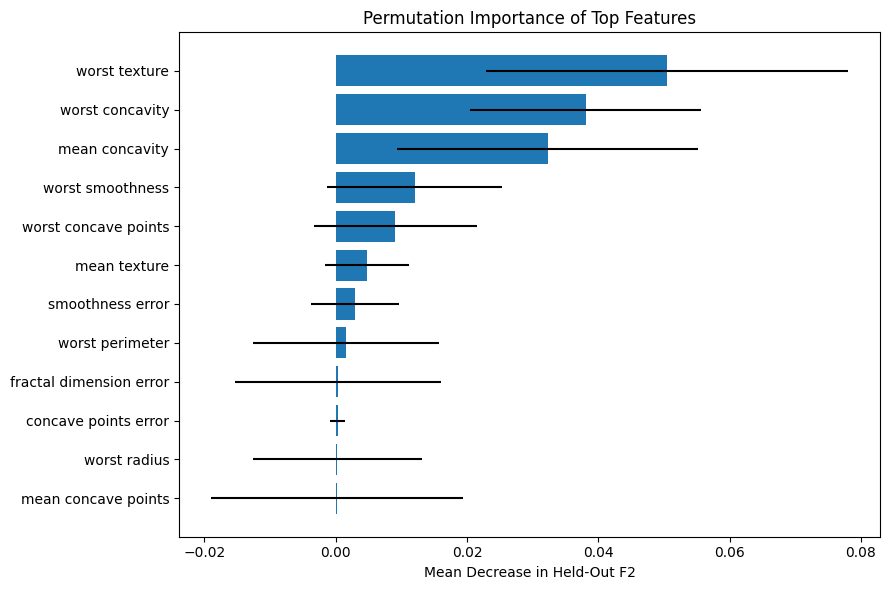

In [23]:
top_importance = importance_df.head(12).sort_values(
    "importance_mean",
    ascending=True,
)

plt.figure(figsize=(9, 6))
plt.barh(
    top_importance["feature"],
    top_importance["importance_mean"],
    xerr=top_importance["importance_std"],
)
plt.xlabel("Mean Decrease in Held-Out F2")
plt.title("Permutation Importance of Top Features")
plt.tight_layout()
plt.show()

# 13. Engineering Validation and Debugging Checks

In [24]:
# A production-style inference function checks schema before prediction.
feature_names = X.columns.tolist()

def predict_single_case(record: dict) -> dict:
    frame = pd.DataFrame([record])

    missing_columns = sorted(set(feature_names) - set(frame.columns))
    extra_columns = sorted(set(frame.columns) - set(feature_names))

    if missing_columns or extra_columns:
        raise ValueError(
            "Feature-schema mismatch. "
            f"Missing={missing_columns}; Extra={extra_columns}"
        )

    frame = frame[feature_names].astype(float)
    probability = float(final_model.predict_proba(frame)[0, 1])
    predicted_class = int(probability >= selected_threshold)

    return {
        "predicted_class": predicted_class,
        "predicted_label": (
            "Malignant-like" if predicted_class == 1 else "Benign-like"
        ),
        "malignant_probability": probability,
        "threshold": selected_threshold,
    }

# Positive test: valid schema
valid_example = X_test.iloc[0].to_dict()
valid_result = predict_single_case(valid_example)
print("Valid inference:", valid_result)

# Negative test: deliberately remove one field and confirm the validator catches it.
invalid_example = valid_example.copy()
invalid_example.pop(feature_names[0])

try:
    predict_single_case(invalid_example)
except ValueError as error:
    print("Expected schema-validation error caught:")
    print(error)

Valid inference: {'predicted_class': 0, 'predicted_label': 'Benign-like', 'malignant_probability': 0.00019134768083116702, 'threshold': 0.5700000000000002}
Expected schema-validation error caught:
Feature-schema mismatch. Missing=['mean radius']; Extra=[]


# 14. Export the Complete Pipeline for Streamlit

In [25]:
# Store feature ranges and representative examples for Streamlit widgets.
feature_statistics = X_train.agg(["min", "max", "median"]).T

benign_example = X_train.loc[y_train == 0].iloc[0].to_dict()
malignant_example = X_train.loc[y_train == 1].iloc[0].to_dict()

model_bundle = {
    "pipeline": final_model,
    "threshold": selected_threshold,
    "feature_names": feature_names,
    "feature_statistics": feature_statistics.to_dict(orient="index"),
    "target_mapping": {0: "Benign-like", 1: "Malignant-like"},
    "model_name": selected_model_name,
    "best_parameters": selected_search.best_params_,
    "test_metrics": {key: float(value) for key, value in test_metrics.items()},
    "example_profiles": {
        "Benign example": benign_example,
        "Malignant example": malignant_example,
    },
    "dataset_description": (
        "Wisconsin Diagnostic Breast Cancer dataset bundled with scikit-learn"
    ),
    "random_state": RANDOM_STATE,
}

model_path = MODEL_DIR / "breast_cancer_pipeline.joblib"
joblib.dump(model_bundle, model_path)

# Include a small schema-valid file for Streamlit batch testing.
sample_batch_path = PROJECT_ROOT / "sample_batch_input.csv"
X_test.head(12).to_csv(sample_batch_path, index=False)

print("Saved model bundle:", model_path)
print("Saved batch sample:", sample_batch_path)
print("Model file size (KB):", round(model_path.stat().st_size / 1024, 2))

Saved model bundle: /mnt/data/COM763_Task1_Breast_Cancer_ML/model/breast_cancer_pipeline.joblib
Saved batch sample: /mnt/data/COM763_Task1_Breast_Cancer_ML/sample_batch_input.csv
Model file size (KB): 27.79


In [26]:
# Final reload test proves the persisted object can perform inference.
reloaded_bundle = joblib.load(
    MODEL_DIR / "breast_cancer_pipeline.joblib"
)

reloaded_pipeline = reloaded_bundle["pipeline"]
reloaded_threshold = float(reloaded_bundle["threshold"])

reloaded_probability = float(
    reloaded_pipeline.predict_proba(X_test.iloc[[0]])[0, 1]
)
reloaded_prediction = int(
    reloaded_probability >= reloaded_threshold
)

assert np.isclose(
    reloaded_probability,
    test_probabilities[0],
)
assert reloaded_prediction == test_predictions[0]

print("Reload test passed.")
print("Probability:", round(reloaded_probability, 4))
print("Predicted class:", reloaded_prediction)

Reload test passed.
Probability: 0.0002
Predicted class: 0


# 15. Final Technical Summary

The notebook has produced:

- a reproducible training and evaluation workflow;
- leakage-safe preprocessing inside scikit-learn pipelines;
- a no-skill baseline and four candidate models;
- stratified five-fold model comparison;
- hyperparameter tuning for two shortlisted models;
- training-only threshold selection;
- one final held-out evaluation;
- confusion-matrix, ROC, precision-recall and importance visuals;
- schema validation and persisted-model reload checks;
- `model/breast_cancer_pipeline.joblib`;
- `sample_batch_input.csv`.

The accompanying `app.py` loads the saved bundle and provides single-case and
batch inference. This educational system must not be used for clinical diagnosis.